### 0. Imports and Global Configuration

This section imports all necessary libraries and sets up global parameters like the number of kernels, number of runs, results directory, and the paper's reported accuracy for various datasets.

In [11]:
!pip install aeon

In [3]:
# ── Standard library ──────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings("ignore")

# ── Numerics ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── aeon ──────────────────────────────────────────────────────────────────
from aeon.datasets import load_classification
from aeon.classification.convolution_based import (
    RocketClassifier,
    MiniRocketClassifier,
)
from aeon.transformations.collection.convolution_based import Rocket

# ── scikit-learn ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ── XGBoost (optional) ───────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[WARNING] xgboost not installed – Method C skipped.\n"
          "          pip install xgboost")

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# =============================================================================
# 0. GLOBAL CONFIGURATION
# =============================================================================

NUM_KERNELS  = 10_000   # paper default
N_RUNS       = 3        # paper uses 10; we use 3 (time constraint)
RESULTS_DIR  = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Paper's reported accuracy from Appendix D, Table 1.
# Source: Dempster et al. 2020, arXiv:1910.13051, Table 1.
# These are the values our reproduction is compared against.
PAPER_ACCURACY = {
    "GunPoint":             1.0000,
    "ItalyPowerDemand":     0.9691,
    "Coffee":               1.0000,
    "Wine":                 0.8074,
    "ECG200":               0.9060,
    "ArrowHead":            0.8051,
    "Chinatown":            0.9802,   # from Appendix E (2018 datasets)
    "SonyAIPARobotSurface1": 0.9241,
}

DATASETS = list(PAPER_ACCURACY.keys())


### 1. Helper: `load_dataset`

This function loads a specified time series classification dataset using `aeon.datasets.load_classification`.

In [4]:
# 1. HELPER: LOAD DATASET

def load_dataset(name: str):
    """
    Returns (X_train, y_train, X_test, y_test).
    aeon format: X has shape (n_cases, n_channels, n_timepoints).
    """
    print(f"  Loading {name} ...", end=" ", flush=True)
    X_train, y_train = load_classification(name, split="train")
    X_test,  y_test  = load_classification(name, split="test")
    print(f"train={X_train.shape[0]}, test={X_test.shape[0]}, "
          f"len={X_train.shape[-1]}")
    return X_train, y_train, X_test, y_test


### 2. Helpers: Custom ROCKET Transforms

These functions apply the ROCKET transform and extract specific features (PPV-only or Max-only) for ablation studies, as discussed in the paper.

In [13]:
# 2. HELPERS: CUSTOM ROCKET TRANSFORMS (for ablations)

def rocket_transform(X_train, X_test, num_kernels=NUM_KERNELS, seed=0):
    """
    Applies Rocket transform and returns (X_train_feats, X_test_feats).
    Output shape: (n, 2*num_kernels) – full ppv+max features.
    StandardScaler is applied since Ridge, RF, and XGBoost all benefit from it.
    """
    transformer = Rocket(n_kernels=num_kernels, random_state=seed)
    X_tr = transformer.fit_transform(X_train)
    X_te = transformer.transform(X_test)

    # Normalise the transformed features
    scaler = StandardScaler(with_mean=True)
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)
    return X_tr, X_te, transformer


def ppv_only(feature_matrix):
    """Return only the PPV columns (even-indexed) from ROCKET's output.
    ROCKET interleaves PPV and max: columns 0,2,4,... are PPV; 1,3,5,... are max.
    (Verified against aeon source: Rocket.fit_transform returns [ppv, max] pairs.)
    """
    return feature_matrix[:, 0::2]   # every other column starting at 0


def max_only(feature_matrix):
    """Return only the max columns (odd-indexed) from ROCKET's output."""
    return feature_matrix[:, 1::2]


### 3. Run One Experiment

The `run_one` function encapsulates the logic for executing a single experimental method on a given dataset and random seed. It supports ROCKET with various classifiers (Ridge, RF, XGBoost), MiniROCKET, and ROCKET with feature ablations (PPV-only, Max-only).

In [12]:
# 3. RUN ONE EXPERIMENT  (single method, single dataset, single seed)

def run_one(method_id, X_train, y_train, X_test, y_test, seed):
    """
    Runs a single method for a single seed.which returns (accuracy, train_time_s).
    """
    # A: ROCKET + Ridge
    if method_id == "A":
        clf = RocketClassifier(n_kernels=NUM_KERNELS, random_state=seed)
        t0  = time.perf_counter()
        clf.fit(X_train, y_train)
        t1  = time.perf_counter()
        acc = accuracy_score(y_test, clf.predict(X_test))
        return acc, t1 - t0

    # B: ROCKET + Random Forest
    elif method_id == "B":
        X_tr, X_te, _ = rocket_transform(X_train, X_test, seed=seed)
        rf = RandomForestClassifier(
            n_estimators=100, random_state=seed, n_jobs=-1
        )
        t0 = time.perf_counter()
        rf.fit(X_tr, y_train)
        t1 = time.perf_counter()
        acc = accuracy_score(y_test, rf.predict(X_te))
        return acc, t1 - t0

    # C: ROCKET + XGBoost
    elif method_id == "C":
        if not XGBOOST_AVAILABLE:
            return np.nan, np.nan
        le          = LabelEncoder()
        y_train_enc = le.fit_transform(y_train)
        y_test_enc  = le.transform(y_test)
        X_tr, X_te, _ = rocket_transform(X_train, X_test, seed=seed)
        xgb = XGBClassifier(
            n_estimators=100, random_state=seed,
            eval_metric="mlogloss", verbosity=0, n_jobs=-1
        )
        t0 = time.perf_counter()
        xgb.fit(X_tr, y_train_enc)
        t1 = time.perf_counter()
        acc = accuracy_score(y_test_enc, xgb.predict(X_te))
        return acc, t1 - t0

    # D: MiniROCKET
    elif method_id == "D":
        clf = MiniRocketClassifier(n_kernels=NUM_KERNELS, random_state=seed)
        t0  = time.perf_counter()
        clf.fit(X_train, y_train)
        t1  = time.perf_counter()
        acc = accuracy_score(y_test, clf.predict(X_test))
        return acc, t1 - t0

    # E: ROCKET ppv-only
    # in paper, ppv >> max; this directly verifies that claim
    elif method_id == "E":
        X_tr_full, X_te_full, _ = rocket_transform(X_train, X_test, seed=seed)
        X_tr = ppv_only(X_tr_full)
        X_te = ppv_only(X_te_full)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    # F: ROCKET max-only
    elif method_id == "F":
        X_tr_full, X_te_full, _ = rocket_transform(X_train, X_test, seed=seed)
        X_tr = max_only(X_tr_full)
        X_te = max_only(X_te_full)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    else:
        raise ValueError(f"Unknown method_id: {method_id}")


### 4. Main Experiment Loop

The `run_experiments` function orchestrates the full experimental loop, iterating through each dataset, method, and random seed. It collects results (accuracy and training time) into a Pandas DataFrame.

In [7]:
# 4. MAIN EXPERIMENT LOOP

# Human-readable method names for the output table
METHOD_LABELS = {
    "A": "A: ROCKET+Ridge (baseline)",
    "B": "B: ROCKET+RF (head ablation)",
    "C": "C: ROCKET+XGBoost (head ablation)",
    "D": "D: MiniROCKET (efficiency)",
    "E": "E: ROCKET ppv-only (feature ablation)",
    "F": "F: ROCKET max-only (feature ablation)",
}

METHODS = list(METHOD_LABELS.keys())
SEEDS   = list(range(N_RUNS))         # [0, 1, 2]


def run_experiments():

    records = []

    for ds_name in DATASETS:
        print(f"\n{'='*65}")
        print(f"Dataset: {ds_name}  "
              f"(paper ROCKET acc = {PAPER_ACCURACY[ds_name]:.4f})")
        print(f"{'='*65}")

        try:
            X_train, y_train, X_test, y_test = load_dataset(ds_name)
        except Exception as e:
            print(f"  [SKIP] {e}")
            continue

        for m_id in METHODS:
            accs, times = [], []
            for seed in SEEDS:
                try:
                    acc, t = run_one(
                        m_id, X_train, y_train, X_test, y_test, seed
                    )
                    accs.append(acc)
                    times.append(t)
                except Exception as e:
                    print(f"    seed={seed} FAILED: {e}")
                    accs.append(np.nan)
                    times.append(np.nan)

            mean_acc  = np.nanmean(accs)
            std_acc   = np.nanstd(accs)
            mean_time = np.nanmean(times)

            # Δ vs paper
            paper_acc = PAPER_ACCURACY.get(ds_name, np.nan)
            delta     = mean_acc - paper_acc

            label = METHOD_LABELS[m_id]
            print(f"  [{m_id}] {label:42s}  "
                  f"acc={mean_acc:.4f}±{std_acc:.4f}  "
                  f"time={mean_time:.2f}s"
                  + (f"  Δ={delta:+.4f}" if m_id == "A" else ""))

            records.append({
                "Dataset":         ds_name,
                "Method":          label,
                "Method_ID":       m_id,
                "Mean_Accuracy":   round(mean_acc,  4),
                "Std_Accuracy":    round(std_acc,   4),
                "Mean_Time_s":     round(mean_time, 3),
                "Paper_Accuracy":  paper_acc,
                "Delta_vs_Paper":  round(delta, 4) if m_id == "A" else np.nan,
            })

    return pd.DataFrame(records)


### 5. Visualisation Functions

This section defines functions to generate various plots for analyzing the experimental results: accuracy comparisons, training time comparisons, and a specific plot for PPV vs. Max feature ablation.

In [8]:
# 5. VISUALISATION

METHOD_COLOURS = {
    "A: ROCKET+Ridge (baseline)":          "#2196F3",
    "B: ROCKET+RF (head ablation)":        "#FF9800",
    "C: ROCKET+XGBoost (head ablation)":   "#4CAF50",
    "D: MiniROCKET (efficiency)":          "#9C27B0",
    "E: ROCKET ppv-only (feature ablation)": "#F44336",
    "F: ROCKET max-only (feature ablation)": "#607D8B",
}


def plot_accuracy_comparison(df: pd.DataFrame):
    """
    Grouped bar chart: accuracy per dataset, one bar per method.
    Paper's reported ROCKET accuracy shown as a dashed horizontal line
    per dataset group — makes reproduction gaps immediately visible.
    """
    datasets = df["Dataset"].unique()
    methods  = df["Method"].unique()
    n_m      = len(methods)
    x        = np.arange(len(datasets))
    width    = 0.13
    offsets  = np.linspace(-(n_m-1)*width/2, (n_m-1)*width/2, n_m)

    fig, ax = plt.subplots(figsize=(20, 6))
    fig.suptitle(
        "ROCKET Reproduction – Accuracy by Dataset and Method\n"
        f"(mean of {N_RUNS} runs; dashed line = paper-reported ROCKET accuracy)",
        fontsize=12, fontweight="bold"
    )

    for i, (method, offset) in enumerate(zip(methods, offsets)):
        vals = []
        errs = []
        for ds in datasets:
            row = df[(df["Dataset"] == ds) & (df["Method"] == method)]
            vals.append(row["Mean_Accuracy"].values[0] if len(row) else np.nan)
            errs.append(row["Std_Accuracy"].values[0] if len(row) else 0)

        ax.bar(
            x + offset, vals,
            width=width,
            yerr=errs,
            capsize=2,
            label=method,
            color=METHOD_COLOURS.get(method, f"C{i}"),
            edgecolor="white", linewidth=0.4,
            error_kw={"elinewidth": 0.8},
        )

    # Draw paper-reported accuracy as dashed horizontal lines per dataset
    for j, ds in enumerate(datasets):
        paper_val = PAPER_ACCURACY.get(ds, None)
        if paper_val:
            ax.hlines(
                paper_val,
                j - 0.45, j + 0.45,
                colors="black", linestyles="--", linewidth=1.2,
                label="Paper result" if j == 0 else "_nolegend_",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=25, ha="right")
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=7.5, loc="lower right", ncol=2)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "accuracy_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"\n[SAVED] {path}")
    plt.show()


def plot_time_comparison(df: pd.DataFrame):
    """Bar chart of training time per method per dataset."""
    datasets = df["Dataset"].unique()
    methods  = df["Method"].unique()
    n_m      = len(methods)
    x        = np.arange(len(datasets))
    width    = 0.13
    offsets  = np.linspace(-(n_m-1)*width/2, (n_m-1)*width/2, n_m)

    fig, ax = plt.subplots(figsize=(20, 5))
    fig.suptitle(
        "ROCKET Reproduction – Training Time by Dataset and Method\n"
        "(lower is better; note log scale)",
        fontsize=12, fontweight="bold"
    )

    for i, (method, offset) in enumerate(zip(methods, offsets)):
        vals = [
            df[(df["Dataset"] == ds) & (df["Method"] == method)]["Mean_Time_s"].values[0]
            if len(df[(df["Dataset"] == ds) & (df["Method"] == method)]) else np.nan
            for ds in datasets
        ]
        ax.bar(
            x + offset, vals, width=width,
            label=method,
            color=METHOD_COLOURS.get(method, f"C{i}"),
            edgecolor="white", linewidth=0.4,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=25, ha="right")
    ax.set_ylabel("Training Time (s)  [log scale]")
    ax.set_yscale("log")
    ax.legend(fontsize=7.5, loc="upper right", ncol=2)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "time_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()


def plot_ppv_vs_max(df: pd.DataFrame):
    """
    Scatter plot mirroring Figure 12 from the paper:
    ppv-only accuracy (y) vs max-only accuracy (x), one point per dataset.
    Points above the diagonal → ppv is better (expected finding from paper).
    """
    ppv_rows = df[df["Method_ID"] == "E"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "ppv_acc"}
    )
    max_rows = df[df["Method_ID"] == "F"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "max_acc"}
    )
    merged = ppv_rows.merge(max_rows, on="Dataset")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(merged["max_acc"], merged["ppv_acc"], s=60, color="#F44336", zorder=3)
    for _, row in merged.iterrows():
        ax.annotate(row["Dataset"], (row["max_acc"], row["ppv_acc"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")

    lims = [
        min(merged["max_acc"].min(), merged["ppv_acc"].min()) - 0.02,
        max(merged["max_acc"].max(), merged["ppv_acc"].max()) + 0.02,
    ]
    ax.plot(lims, lims, "k--", linewidth=0.8, label="equal accuracy")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("max-only accuracy")
    ax.set_ylabel("ppv-only accuracy")
    ax.set_title("ppv vs max (reproducing paper Fig. 12)\nPoints above diagonal → ppv wins",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "ppv_vs_max.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()


### 6. Console Summary Functions

These functions are responsible for printing formatted tables to the console, summarizing the reproduction accuracy against the paper's reported values and providing an overall summary of mean accuracy and time per method.

In [9]:
# 6. CONSOLE SUMMARY

def print_reproduction_table(df: pd.DataFrame):
    """
    Prints the critical table for your report:
    Paper accuracy vs our reproduced accuracy (Method A only), with Δ.
    """
    baseline = df[df["Method_ID"] == "A"][[
        "Dataset", "Mean_Accuracy", "Std_Accuracy", "Paper_Accuracy", "Delta_vs_Paper"
    ]].copy()
    baseline.columns = [
        "Dataset", "Reproduced Acc", "Std", "Paper Acc", "Δ (ours - paper)"
    ]
    print("\n" + "="*70)
    print("REPRODUCTION TABLE (Method A: ROCKET + Ridge vs. Paper)")
    print("Dempster et al. report means over 10 runs; we use", N_RUNS, "runs.")
    print("="*70)
    print(baseline.to_string(index=False))
    mean_delta = baseline["Δ (ours - paper)"].mean()
    print(f"\n  Mean Δ across datasets: {mean_delta:+.4f}")
    print("="*70)

def print_method_summary(df: pd.DataFrame):
    """Mean accuracy and time per method across all datasets."""
    summary = (
        df.groupby("Method")[["Mean_Accuracy", "Mean_Time_s"]]
          .mean()
          .round(4)
    )
    summary.columns = ["Mean Accuracy (avg over datasets)", "Mean Time s"]
    print("\n" + "="*70)
    print("ALL-METHOD SUMMARY (averaged over all datasets)")
    print("="*70)
    print(summary.to_string())


### 7. Entry Point: Run All Experiments and Generate Outputs

This is the main execution block. It sets up the study, runs all defined experiments, saves the results to a CSV file, prints summary tables to the console, and generates the various plots.


ROCKET Reproduction Study – COMP41850
Datasets  : ['GunPoint', 'ItalyPowerDemand', 'Coffee', 'Wine', 'ECG200', 'ArrowHead', 'Chinatown', 'SonyAIPARobotSurface1']
Methods   : ['A: ROCKET+Ridge (baseline)', 'B: ROCKET+RF (head ablation)', 'C: ROCKET+XGBoost (head ablation)', 'D: MiniROCKET (efficiency)', 'E: ROCKET ppv-only (feature ablation)', 'F: ROCKET max-only (feature ablation)']
Seeds     : [0, 1, 2]  (3 runs each)
Kernels   : 10,000  →  20,000 features
Ground truth from: Dempster et al. Table 1 (arXiv:1910.13051)


Dataset: GunPoint  (paper ROCKET acc = 1.0000)
  Loading GunPoint ... train=50, test=150, len=150
  [A] A: ROCKET+Ridge (baseline)                  acc=1.0000±0.0000  time=5.85s  Δ=+0.0000
  [B] B: ROCKET+RF (head ablation)                acc=0.9822±0.0063  time=0.23s
  [C] C: ROCKET+XGBoost (head ablation)           acc=0.9333±0.0411  time=2.34s
  [D] D: MiniROCKET (efficiency)                  acc=0.9933±0.0000  time=7.40s
  [E] E: ROCKET ppv-only (feature ablation) 

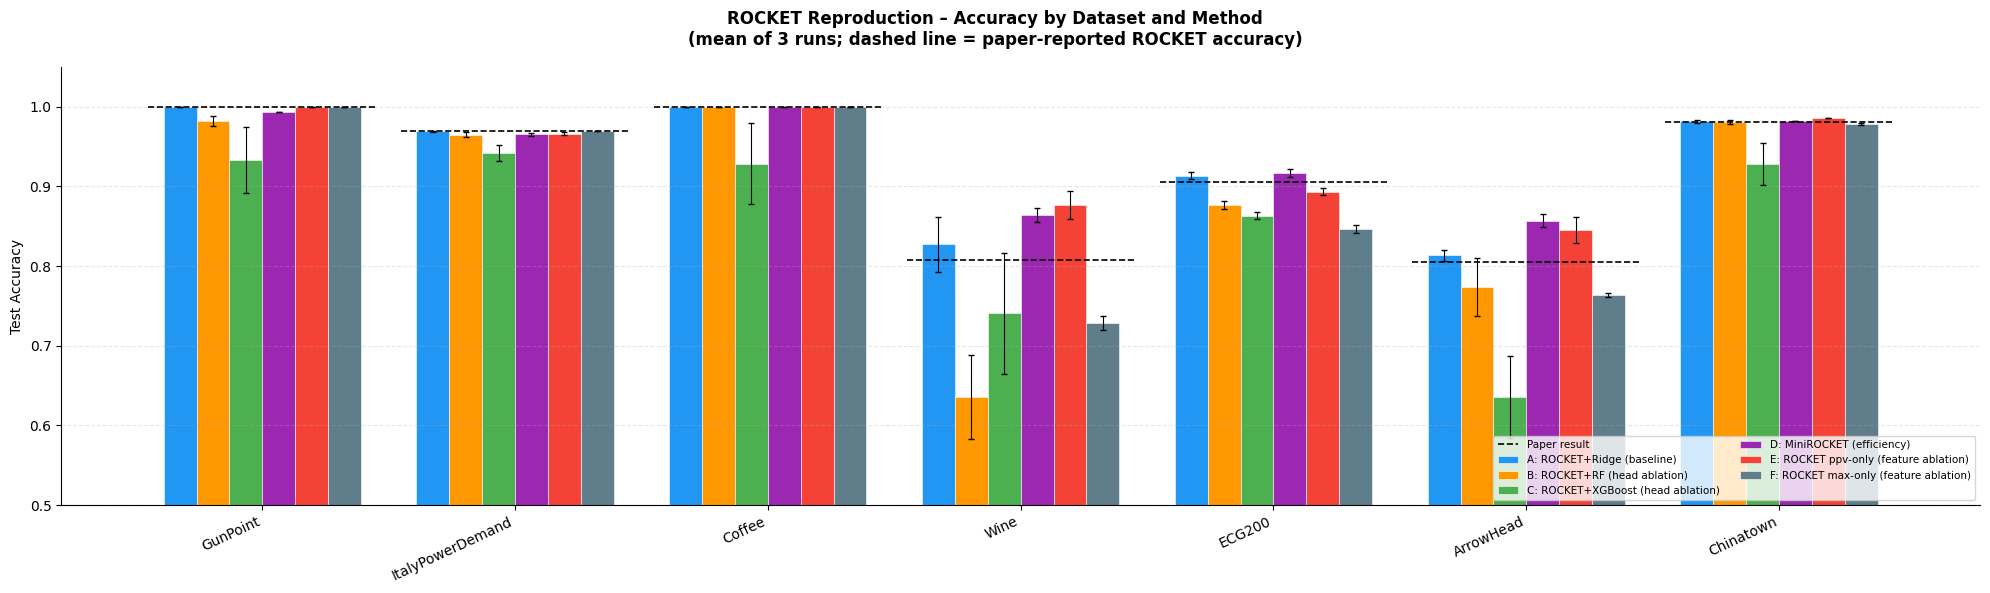

[SAVED] results/time_comparison.png


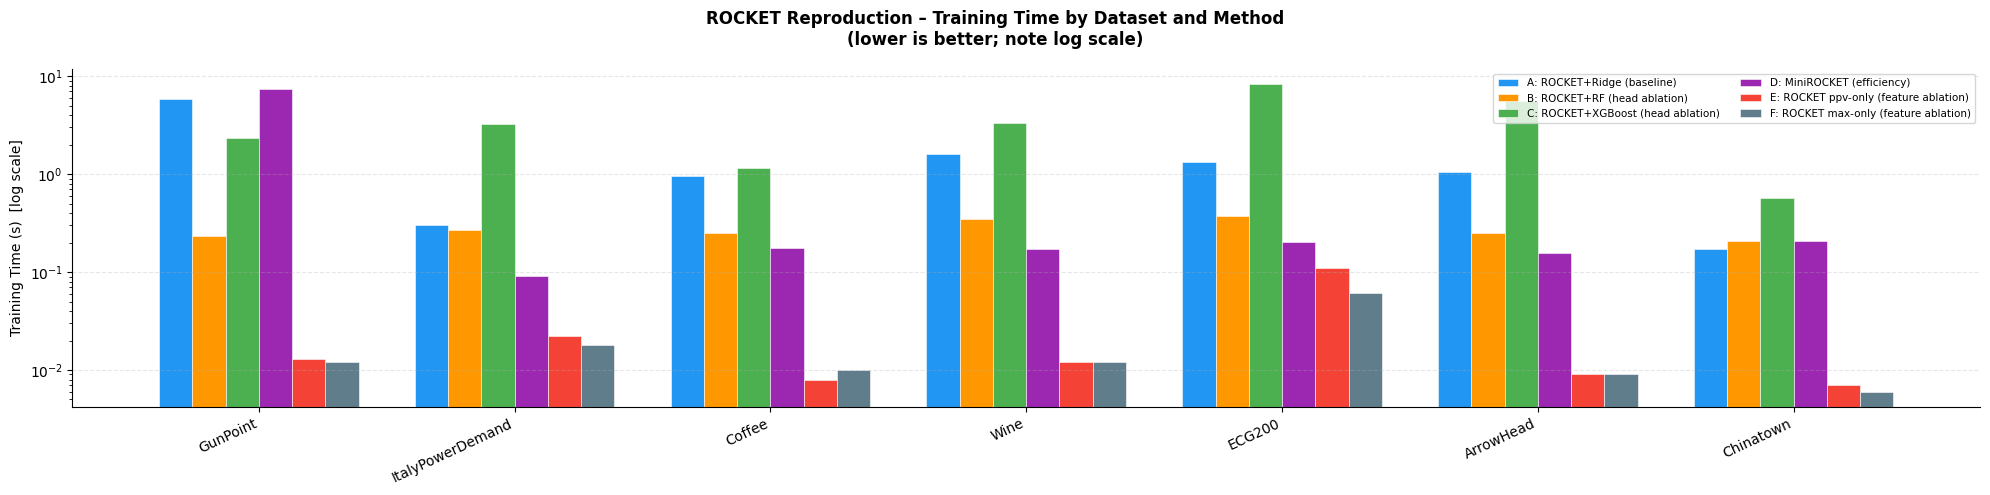

[SAVED] results/ppv_vs_max.png


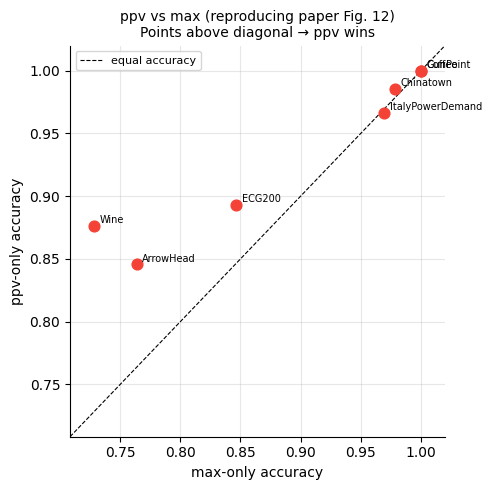


[DONE] All results saved to ./results/


In [14]:
# 7. ENTRY POINT

if __name__ == "__main__":
    print("\n" + "="*65)
    print("ROCKET Reproduction Study – COMP41850")
    print(f"Datasets  : {DATASETS}")
    print(f"Methods   : {list(METHOD_LABELS.values())}")
    print(f"Seeds     : {SEEDS}  ({N_RUNS} runs each)")
    print(f"Kernels   : {NUM_KERNELS:,}  →  {2*NUM_KERNELS:,} features")
    print("Ground truth from: Dempster et al. Table 1 (arXiv:1910.13051)")
    print("="*65 + "\n")

    # Run experiments
    results_df = run_experiments()

    # Save to CSV
    csv_path = os.path.join(RESULTS_DIR, "results.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"\n[SAVED] {csv_path}")

    # Console tables
    print_reproduction_table(results_df)
    print_method_summary(results_df)

    # Plots
    plot_accuracy_comparison(results_df)
    plot_time_comparison(results_df)
    plot_ppv_vs_max(results_df)

    print("\n[DONE] All results saved to ./results/")
